# Voice Anti-Spoofing — Full Classification Pipeline

**Dataset structure expected:**
```
AUDIO/
  real/          ← genuine recorded voices
  fake/
    tts/         ← Text-to-Speech generated voices
    replay/      ← replay attack voices
```

**Supports two modes:**
- `MODE = 'binary'`  → Real (0) vs Fake (1)
- `MODE = 'multiclass'` → Real (0) vs TTS (1) vs Replay (2)

## 1. Imports

In [1]:
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from collections import Counter
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import Input, layers, models, callbacks, regularizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score



## 2. Configuration

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
# Update this path if running locally or on Kaggle
DATASET_PATH = r'/kaggle/input/datasets/faisalziyadahmed/audio-data-set/Audio'
OUTPUT_DIR = Path('saved_models')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Audio Parameters ───────────────────────────────────────────────────────
SR         = 16000
DURATION   = 3
N_MFCC     = 40
HOP_LENGTH = 160
N_FFT      = 512
MAX_LEN    = int(SR * DURATION / HOP_LENGTH) + 1

# ── Mode & Training Config ─────────────────────────────────────────────────
MODE       = 'binary'  # 'binary' or 'multiclass'
BATCH_SIZE = 16
EPOCHS     = 80
SEED       = 42
AUGMENT    = True
AUG_FACTOR = 3

if MODE == 'binary':
    LABEL_MAP   = {'real': 0, 'tts': 1, 'replay': 1}
    CLASS_NAMES = ['Real', 'Fake']
    N_CLASSES   = 1
else:
    LABEL_MAP   = {'real': 0, 'tts': 1, 'replay': 2}
    CLASS_NAMES = ['Real', 'TTS', 'Replay']
    N_CLASSES   = 3

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPUs available    : {tf.config.list_physical_devices('GPU')}")
print(f"Mode              : {MODE}")
print(f"Max Frames        : {MAX_LEN}")

TensorFlow Version: 2.20.0
GPUs available    : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mode              : binary
Max Frames        : 301


## 3. Feature Extraction

We extract **three complementary feature sets** stacked into one 2D map:

| Feature | What it captures | Why useful for spoofing detection |
|---|---|---|
| MFCC | Vocal tract shape (spectral envelope) | TTS systems often have unnatural formant patterns |
| Delta (Δ) | Rate of change across time | Replay voices have unnatural temporal transitions |
| Delta-Delta (ΔΔ) | Acceleration of change | TTS prosody artifacts show up in 2nd derivative |

In [3]:
def signal_to_features(signal: np.ndarray) -> np.ndarray:
    """Convert raw waveform → MFCC + Delta + Delta-Delta (120, MAX_LEN)"""
    mfcc = librosa.feature.mfcc(
        y=signal, sr=SR, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    delta = librosa.feature.delta(mfcc, order=1)
    delta2 = librosa.feature.delta(mfcc, order=2)
    feat = np.vstack([mfcc, delta, delta2])

    if feat.shape[1] < MAX_LEN:
        feat = np.pad(feat, ((0, 0), (0, MAX_LEN - feat.shape[1])))
    else:
        feat = feat[:, :MAX_LEN]
    return feat


def load_audio(file_path: str) -> np.ndarray:
    """Load, trim, and pad/truncate audio signal"""
    sig, _ = librosa.load(file_path, sr=SR)
    sig, _ = librosa.effects.trim(sig, top_db=20)
    target = SR * DURATION
    if len(sig) < target:
        sig = np.pad(sig, (0, max(0, target - len(sig))))
    else:
        sig = sig[:target]
    return sig.astype(np.float32)




## 4. Augument the data

In [4]:
def augment_signal(signal: np.ndarray, sr: int = SR) -> np.ndarray:
    """Apply random acoustic perturbations to raw signal"""
    aug = signal.copy()
    choice = np.random.randint(0, 5)

    if choice == 0:
        noise_level = np.random.uniform(0.003, 0.015)
        aug = aug + noise_level * np.random.randn(len(aug))
    elif choice == 1:
        rate = np.random.uniform(0.88, 1.12)
        aug = librosa.effects.time_stretch(aug, rate=rate)
    elif choice == 2:
        steps = np.random.uniform(-2.5, 2.5)
        aug = librosa.effects.pitch_shift(aug, sr=sr, n_steps=steps)
    elif choice == 3:
        gain = np.random.uniform(0.6, 1.4)
        aug = aug * gain
    elif choice == 4:
        shift = np.random.randint(sr // 10, sr // 3)
        aug = np.roll(aug, shift)
        aug[:shift] = 0

    target = sr * DURATION
    if len(aug) < target:
        aug = np.pad(aug, (0, target - len(aug)))
    else:
        aug = aug[:target]

    return aug.astype(np.float32)


def collect_files(dataset_path: str, label_map: dict):
    pairs = []
    real_dir = os.path.join(dataset_path, 'real')
    if os.path.isdir(real_dir):
        for f in os.listdir(real_dir):
            if f.lower().endswith(('.wav', '.mp3', '.flac')):
                pairs.append((os.path.join(real_dir, f), label_map['real']))

    fake_dir = os.path.join(dataset_path, 'fake')
    if os.path.isdir(fake_dir):
        for entry in os.listdir(fake_dir):
            entry_path = os.path.join(fake_dir, entry)
            if os.path.isdir(entry_path) and entry in label_map:
                for f in os.listdir(entry_path):
                    if f.lower().endswith(('.wav', '.mp3', '.flac')):
                        pairs.append((os.path.join(entry_path, f), label_map[entry]))
            elif entry.lower().endswith(('.wav', '.mp3', '.flac')):
                pairs.append((entry_path, label_map.get('tts', 1)))
    return pairs

## 5. Preprocess — Normalise & Split

In [5]:
# 1. Collect all file paths
all_pairs = collect_files(DATASET_PATH, LABEL_MAP)
print(f"Total raw audio files: {len(all_pairs)}")

file_paths = [p[0] for p in all_pairs]
labels = np.array([p[1] for p in all_pairs])

# 2. Stratified Train/Val/Test Split (BEFORE Augmentation and Feature Extraction)
train_paths, test_paths, y_train_raw, y_test_raw = train_test_split(
    file_paths, labels, test_size=0.15, random_state=SEED, stratify=labels
)
train_paths, val_paths, y_train_raw, y_val_raw = train_test_split(
    train_paths, y_train_raw, test_size=0.15/0.85, random_state=SEED, stratify=y_train_raw
)

print(f"Split Count -> Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

# 3. Process Training Signals (Augmentation applied ONLY here)
train_features, y_train_final = [], []
for path, label in tqdm(zip(train_paths, y_train_raw), total=len(train_paths), desc="Processing Train"):
    sig = load_audio(path)
    train_features.append(signal_to_features(sig))
    y_train_final.append(label)

    if AUGMENT:
        for _ in range(AUG_FACTOR):
            aug_sig = augment_signal(sig)
            train_features.append(signal_to_features(aug_sig))
            y_train_final.append(label)

# 4. Process Validation and Test Signals (No Augmentation)
val_features, y_val_final = [], []
for path, label in tqdm(zip(val_paths, y_val_raw), total=len(val_paths), desc="Processing Val"):
    sig = load_audio(path)
    val_features.append(signal_to_features(sig))
    y_val_final.append(label)

test_features, y_test_final = [], []
for path, label in tqdm(zip(test_paths, y_test_raw), total=len(test_paths), desc="Processing Test"):
    sig = load_audio(path)
    test_features.append(signal_to_features(sig))
    y_test_final.append(label)

X_train = np.array(train_features)
X_val   = np.array(val_features)
X_test  = np.array(test_features)
y_train = np.array(y_train_final)
y_val   = np.array(y_val_final)
y_test  = np.array(y_test_final)

# 5. Fit Scaler ONLY on Training Set
N_tr, F, T = X_train.shape
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(N_tr, -1)).reshape(N_tr, F, T, 1)
X_val   = scaler.transform(X_val.reshape(X_val.shape[0], -1)).reshape(X_val.shape[0], F, T, 1)
X_test  = scaler.transform(X_test.reshape(X_test.shape[0], -1)).reshape(X_test.shape[0], F, T, 1)

# Categorical targets if multiclass
if MODE == 'multiclass':
    y_train_m = tf.keras.utils.to_categorical(y_train, N_CLASSES)
    y_val_m   = tf.keras.utils.to_categorical(y_val, N_CLASSES)
    y_test_m  = tf.keras.utils.to_categorical(y_test, N_CLASSES)
else:
    y_train_m, y_val_m, y_test_m = y_train, y_val, y_test

# Compute Class Weights
counts = Counter(y_train)
class_weight = {cls: len(y_train) / (len(counts) * cnt) for cls, cnt in counts.items()}
print(f"Training shape: {X_train.shape} | Class Weights: {class_weight}")

Total raw audio files: 376
Split Count -> Train: 262 | Val: 57 | Test: 57


Processing Test: 100%|██████████| 57/57 [00:01<00:00, 52.39it/s]


Training shape: (1048, 120, 301, 1) | Class Weights: {np.int64(1): 0.8506493506493507, np.int64(0): 1.212962962962963}


## 6. Build CNN Model

The architecture adapts automatically to binary or multiclass mode.

In [6]:
def build_light_cnn(input_shape, n_classes, mode):
    inp = Input(shape=input_shape, name='input')

    # Block 1
    x = layers.Conv2D(16, (3, 3), padding='same',
                      kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(1e-3))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.SpatialDropout2D(0.2)(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = layers.Conv2D(32, (3, 3), padding='same',
                      kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(1e-3))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.SpatialDropout2D(0.2)(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Dense Aggregation
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, kernel_regularizer=regularizers.l2(1e-3))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.6)(x)

    if mode == 'binary':
        out = layers.Dense(1, activation='sigmoid')(x)
    else:
        out = layers.Dense(n_classes, activation='softmax')(x)

    return models.Model(inp, out, name='LightVoiceCNN')

## 7. Compile & Train

In [9]:
model = build_light_cnn(X_train.shape[1:], N_CLASSES, MODE)


loss = 'binary_crossentropy' if MODE == 'binary' else 'categorical_crossentropy'
metrics = ['accuracy', tf.keras.metrics.AUC(name='auc')]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=loss,
    metrics=metrics
)

checkpoint_path = os.path.join(OUTPUT_DIR, 'best_model.keras')
cb_list = [
    callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint(checkpoint_path, monitor='val_auc', save_best_only=True, mode='max', verbose=0)
]

history = model.fit(
    X_train, y_train_m,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val_m),
    class_weight=class_weight,
    callbacks=cb_list,
    verbose=1
)

I0000 00:00:1787432946.417405    7212 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787432946.419520    7212 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/80


2026-08-22 21:09:12.170801: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-22 21:09:12.447130: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


13/66 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5119 - auc: 0.6059 - loss: 1.0062

I0000 00:00:1787432955.403078    7285 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


62/66 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5139 - auc: 0.5636 - loss: 1.0204

2026-08-22 21:09:17.442374: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-22 21:09:17.729634: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


66/66 ━━━━━━━━━━━━━━━━━━━━ 16s 125ms/step - accuracy: 0.5095 - auc: 0.5350 - loss: 1.0544 - val_accuracy: 0.5965 - val_auc: 0.8384 - val_loss: 0.7937 - learning_rate: 5.0000e-04
Epoch 2/80
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5038 - auc: 0.5170 - loss: 1.0193 - val_accuracy: 0.5789 - val_auc: 0.8662 - val_loss: 0.7778 - learning_rate: 5.0000e-04
Epoch 3/80
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5372 - auc: 0.5306 - loss: 0.9877 - val_accuracy: 0.6140 - val_auc: 0.8807 - val_loss: 0.7630 - learning_rate: 5.0000e-04
Epoch 4/80
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5382 - auc: 0.5579 - loss: 0.9377 - val_accuracy: 0.6140 - val_auc: 0.8687 - val_loss: 0.7560 - learning_rate: 5.0000e-04
Epoch 5/80
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5305 - auc: 0.5476 - loss: 0.9386 - val_accuracy: 0.6316 - val_auc: 0.8794 - val_loss: 0.7583 - learning_rate: 5.0000e-04
Epoch 6/80
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5200 - au

## 8. Evaluate on Test Set

In [10]:
# 1. Validation Calibration
val_probs = model.predict(X_val, verbose=0)
if MODE == 'binary':
    val_probs_flat = val_probs.flatten()
    y_val_eval = y_val
else:
    val_probs_flat = 1 - val_probs[:, 0]
    y_val_eval = (y_val > 0).astype(int)

fpr, tpr, thresholds = roc_curve(y_val_eval, val_probs_flat)
fnr = 1 - tpr
eer_idx = np.argmin(np.abs(fpr - fnr))
EER_THRESHOLD = float(thresholds[eer_idx])
EER_VAL = (fpr[eer_idx] + fnr[eer_idx]) / 2

print(f"Validation EER: {EER_VAL * 100:.2f}% | Calibrated Threshold: {EER_THRESHOLD:.4f}")

# 2. Test Set Evaluation on Unseen Test Set
test_probs = model.predict(X_test, verbose=0)
if MODE == 'binary':
    test_probs_flat = test_probs.flatten()
    y_pred = (test_probs_flat >= EER_THRESHOLD).astype(int)
else:
    y_pred = np.argmax(test_probs, axis=1)

print("\n" + "=" * 55)
print("TEST SET EVALUATION (Unseen & Data-Leak Free):")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

# 3. Save Serialized Config & Scaler for Inference
with open(os.path.join(OUTPUT_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

config = {
    'mode': MODE,
    'class_names': CLASS_NAMES,
    'threshold': EER_THRESHOLD,
    'sample_rate': SR,
    'duration': DURATION,
    'n_mfcc': N_MFCC,
    'n_fft': N_FFT,
    'hop_length': HOP_LENGTH,
    'max_pad_len': MAX_LEN,
}
with open(os.path.join(OUTPUT_DIR, 'model_config.pkl'), 'wb') as f:
    pickle.dump(config, f)

print(f"Saved artifacts to {OUTPUT_DIR}/")

Validation EER: 23.11% | Calibrated Threshold: 0.5713

TEST SET EVALUATION (Unseen & Data-Leak Free):
              precision    recall  f1-score   support

        Real       0.77      0.71      0.74        24
        Fake       0.80      0.85      0.82        33

    accuracy                           0.79        57
   macro avg       0.79      0.78      0.78        57
weighted avg       0.79      0.79      0.79        57

Saved artifacts to saved_models/


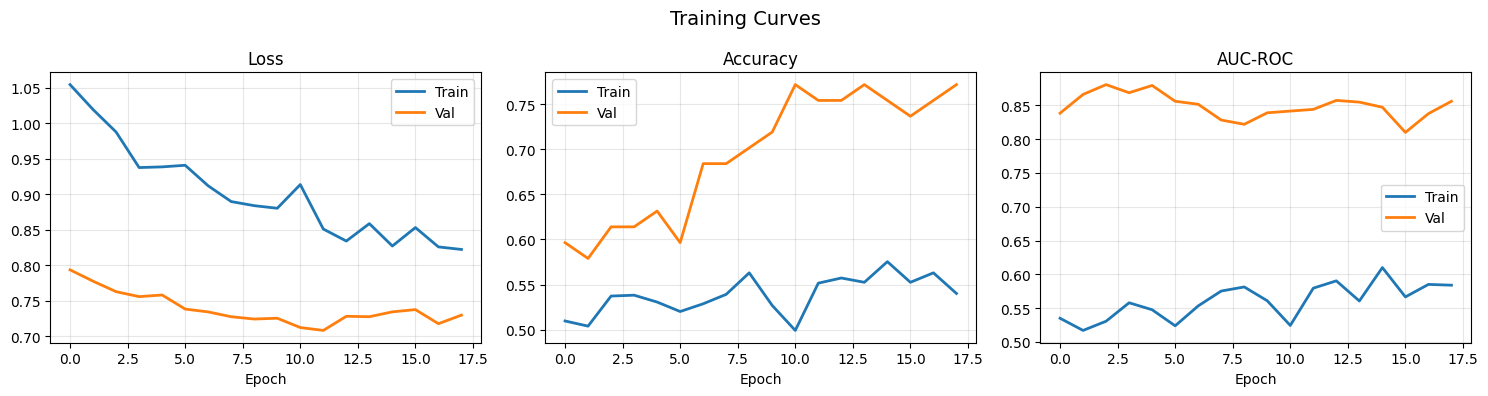


Final train acc : 0.540
Final val acc   : 0.772
Gap             : -0.232
  ✓ Low gap → model is generalising well!


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Training Curves', fontsize=14)

for ax, (train_key, val_key, title) in zip(axes, [
    ('loss',     'val_loss',     'Loss'),
    ('accuracy', 'val_accuracy', 'Accuracy'),
    ('auc',      'val_auc',      'AUC-ROC'),
]):
    ax.plot(history.history[train_key], label='Train', linewidth=2)
    ax.plot(history.history[val_key],   label='Val',   linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Highlight overfitting zone
    if train_key == 'loss':
        train_vals = history.history[train_key]
        val_vals   = history.history[val_key]
        gap = [v - t for t, v in zip(train_vals, val_vals)]
        if max(gap) > 0.3:
            ax.text(0.5, 0.5, '⚠ Overfitting detected',
                    transform=ax.transAxes, ha='center',
                    color='red', fontsize=9, alpha=0.7)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

# Quick overfitting check
final_train_acc = history.history['accuracy'][-1]
final_val_acc   = history.history['val_accuracy'][-1]
gap             = final_train_acc - final_val_acc
print(f'\nFinal train acc : {final_train_acc:.3f}')
print(f'Final val acc   : {final_val_acc:.3f}')
print(f'Gap             : {gap:.3f}')
if gap > 0.15:
    print('  ⚠ High gap → OVERFITTING. Need more augmentation or simpler model.')
elif gap < 0.05:
    print('  ✓ Low gap → model is generalising well!')

THRESHOLD CALIBRATION ON VALIDATION SET:
AUC-ROC             : 0.8838
EER                 : 23.11%
EER Threshold       : 0.5713 (Recommended for balanced security)
Best F1 Threshold   : 0.5805 (Max F1: 0.8475)
Default Threshold   : 0.5000


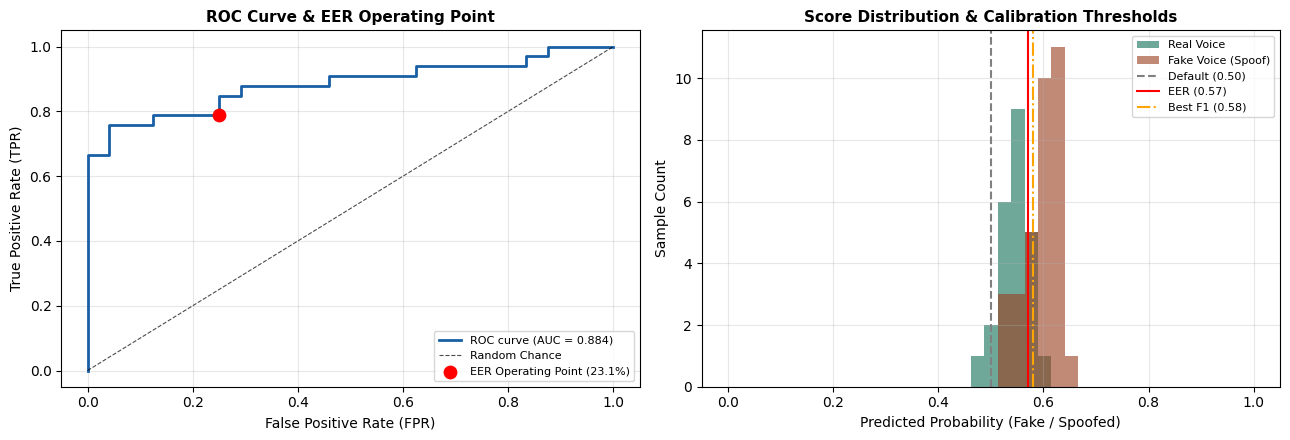


→ Selected Decision Threshold: 0.5713


In [12]:
from sklearn.metrics import roc_curve, auc, f1_score

# 1. Get model predictions on the validation set
val_probs = model.predict(X_val, verbose=0)

if MODE == 'binary':
    val_probs_flat = val_probs.flatten()
    y_val_eval = np.array(y_val, dtype=int)
else:
    # Multiclass mode: calculate probability of NOT being Real (1 - P(Real))
    val_probs_flat = 1.0 - val_probs[:, 0]
    y_val_eval = (np.array(y_val) > 0).astype(int)

# 2. Compute ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_val_eval, val_probs_flat)
roc_auc = auc(fpr, tpr)
fnr = 1.0 - tpr

# Method 1: Equal Error Rate (EER) Threshold
eer_idx = np.argmin(np.abs(fpr - fnr))
EER = float((fpr[eer_idx] + fnr[eer_idx]) / 2.0)
EER_THRESHOLD = float(thresholds[eer_idx])

# Method 2: F1-Optimal Threshold
# Filter out scikit-learn's initial threshold (> 1.0) for valid evaluation
valid_thresholds = [t for t in thresholds if 0.0 <= t <= 1.0]
if not valid_thresholds:
    valid_thresholds = list(np.linspace(0.01, 0.99, 100))

f1_scores = [
    f1_score(y_val_eval, (val_probs_flat >= t).astype(int), zero_division=0)
    for t in valid_thresholds
]
best_f1_idx = int(np.argmax(f1_scores))
F1_THRESHOLD = float(valid_thresholds[best_f1_idx])
BEST_F1_SCORE = float(f1_scores[best_f1_idx])

print('=' * 55)
print('THRESHOLD CALIBRATION ON VALIDATION SET:')
print('=' * 55)
print(f'AUC-ROC             : {roc_auc:.4f}')
print(f'EER                 : {EER * 100:.2f}%')
print(f'EER Threshold       : {EER_THRESHOLD:.4f} (Recommended for balanced security)')
print(f'Best F1 Threshold   : {F1_THRESHOLD:.4f} (Max F1: {BEST_F1_SCORE:.4f})')
print(f'Default Threshold   : 0.5000')

# 3. Visual Comparison of Thresholds
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Subplot 1: ROC Curve
ax1.plot(fpr, tpr, color='#185FA5', linewidth=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.7, label='Random Chance')
ax1.scatter(fpr[eer_idx], tpr[eer_idx], color='red', s=80, zorder=5,
            label=f'EER Operating Point ({EER * 100:.1f}%)')
ax1.set_xlabel('False Positive Rate (FPR)', fontsize=10)
ax1.set_ylabel('True Positive Rate (TPR)', fontsize=10)
ax1.set_title('ROC Curve & EER Operating Point', fontsize=11, fontweight='bold')
ax1.legend(loc='lower right', fontsize=8)
ax1.grid(True, alpha=0.3)

# Subplot 2: Score Distribution
real_scores = val_probs_flat[y_val_eval == 0]
fake_scores = val_probs_flat[y_val_eval == 1]
bins = np.linspace(0.0, 1.0, 40)

ax2.hist(real_scores, bins=bins, alpha=0.6, color='#0F6E56', label='Real Voice', density=False)
ax2.hist(fake_scores, bins=bins, alpha=0.6, color='#993C1D', label='Fake Voice (Spoof)', density=False)
ax2.axvline(0.5, color='gray', linewidth=1.5, linestyle='--', label='Default (0.50)')
ax2.axvline(EER_THRESHOLD, color='red', linewidth=1.5, linestyle='-', label=f'EER ({EER_THRESHOLD:.2f})')
ax2.axvline(F1_THRESHOLD, color='orange', linewidth=1.5, linestyle='-.', label=f'Best F1 ({F1_THRESHOLD:.2f})')
ax2.set_xlabel('Predicted Probability (Fake / Spoofed)', fontsize=10)
ax2.set_ylabel('Sample Count', fontsize=10)
ax2.set_title('Score Distribution & Calibration Thresholds', fontsize=11, fontweight='bold')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
calibration_plot_path = OUTPUT_DIR / 'threshold_calibration.png'
plt.savefig(calibration_plot_path, dpi=150)
plt.show()

# Final selection of threshold to be used in evaluation and inference
BEST_THRESHOLD = EER_THRESHOLD
print(f'\n→ Selected Decision Threshold: {BEST_THRESHOLD:.4f}')

## Model


In [13]:
def predict_voice(file_path: str, model_dir: str = 'saved_models'):
    model = tf.keras.models.load_model(os.path.join(model_dir, 'best_model.keras'))
    with open(os.path.join(model_dir, 'scaler.pkl'), 'rb') as f:
        scaler_obj = pickle.load(f)
    with open(os.path.join(model_dir, 'model_config.pkl'), 'rb') as f:
        cfg = pickle.load(f)

    sig = load_audio(file_path)
    feat = signal_to_features(sig)
    F_dim, T_dim = feat.shape
    flat = scaler_obj.transform(feat.flatten().reshape(1, -1))
    inp = flat.reshape(1, F_dim, T_dim, 1)

    raw = model.predict(inp, verbose=0)
    thr = cfg['threshold']
    names = cfg['class_names']

    if cfg['mode'] == 'binary':
        prob = float(raw[0][0])
        pred_idx = 1 if prob >= thr else 0
        label = names[pred_idx]
        confidence = prob if pred_idx == 1 else 1.0 - prob
        scores = {names[0]: 1.0 - prob, names[1]: prob}
    else:
        probs = raw[0]
        pred_idx = int(np.argmax(probs))
        label = names[pred_idx]
        confidence = float(probs[pred_idx])
        scores = {name: float(p) for name, p in zip(names, probs)}

    icon = '✅' if label == 'Real' else '❌'
    print(f"\n{'-'*44}")
    print(f"  File       : {os.path.basename(file_path)}")
    print(f"  Prediction : {icon}  {label.upper()}")
    print(f"  Confidence : {confidence * 100:.1f}%")
    print(f"  Threshold  : {thr:.4f}")
    print(f"  Scores:")
    for cls, sc in scores.items():
        bar = '█' * int(sc * 25)
        print(f"    {cls:10s} {bar:<25s} {sc * 100:.1f}%")
    print(f"{'-'*44}\n")

# Example usage:
# predict_voice('/kaggle/input/datasets/faisalziyadahmed/audio-data-set/Audio/real/sample.wav')

In [14]:
# Run prediction on the target audio file
result = predict_voice('/kaggle/input/datasets/faisalziyadahmed/test-audio-p/Sample (2).wav')


--------------------------------------------
  File       : Sample (2).wav
  Prediction : ❌  FAKE
  Confidence : 66.8%
  Threshold  : 0.5713
  Scores:
    Real       ████████                  33.2%
    Fake       ████████████████          66.8%
--------------------------------------------

